In [1]:
from typing import List, Dict, Optional
import torch

import sys 
sys.path.append(".")
sys.path.append("..")

from poisson_pipeline import StormPipeline
from config import RunConfig
from run import run_on_prompt, get_indices_to_alter
from utils import vis_utils
from utils.ptp_utils import AttentionStore

# %load_ext autoreload 
# %autoreload 2

# Load Model Weights

In [2]:
NUM_DIFFUSION_STEPS = 50
GUIDANCE_SCALE = 7.5
MAX_NUM_WORDS = 77
device = torch.device('cuda:0') if torch.cuda.is_available() else torch.device('cpu')
stable = StormPipeline.from_pretrained("CompVis/stable-diffusion-v1-4").to(device)
tokenizer = stable.tokenizer

/root/STORM/venv/lib/python3.10/site-packages/huggingface_hub/file_download.py:1142: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
safety_checker/pytorch_model.fp16.safetensors not found


Fetching 21 files:   0%|          | 0/21 [00:00<?, ?it/s]

The config attributes {'scaling_factor': 0.18215} were passed to AutoencoderKL, but are not expected and will be ignored. Please verify your config.json configuration file.


# Pipeline Wrapper

In [3]:
import numpy as np
print(np.__version__)
import torch
print(torch.__version__)
x = np.array([1, 2, 3])
t = torch.from_numpy(x)
print(t)  # should print tensor([1, 2, 3])

1.26.4
2.1.0+cu118
tensor([1, 2, 3])


In [4]:
def run_and_display(prompts: List[str],
                    controller: AttentionStore,
                    indices_to_alter: List[int],
                    generator: torch.Generator,
                    run_standard_sd: bool = False,
                    scale_factor: int = 20,
                    thresholds: Dict[int, float] = {0:0.05, 10: 0.5, 20: 0.8},
                    max_iter_to_alter: int = 25,
                    display_output: bool = False,
                    sd_2_1: bool = False):
    config = RunConfig(run_standard_sd=run_standard_sd,
                       scale_factor=scale_factor,
                       thresholds=thresholds,
                       max_iter_to_alter=max_iter_to_alter,
                       sd_2_1=sd_2_1)
    image = run_on_prompt(model=stable,
                          prompt=prompts,
                          controller=controller,
                          token_indices=indices_to_alter,
                          seed=generator,
                          config=config)
    if display_output:
        display(image)
    return image

In [5]:
def generate_images_for_method(prompt: str,
                               seeds: List[int],
                               indices_to_alter: Optional[List[int]] = None,
                               is_storm_true: bool = True,
                               sd_2_1: bool = False):
    token_indices = get_indices_to_alter(stable, prompt) if indices_to_alter is None else indices_to_alter
    images = []
    for seed in seeds:
        g = torch.Generator('cuda').manual_seed(seed)
        prompts = [prompt]
        controller = AttentionStore()
        run_standard_sd = False if is_storm_true else True
        image = run_and_display(prompts=prompts,
                                controller=controller,
                                indices_to_alter=token_indices,
                                generator=g,
                                run_standard_sd=run_standard_sd,
                                sd_2_1=sd_2_1)
        images.append(image.resize((256, 256)))
    grid = vis_utils.get_image_grid(images)
    display(grid)

# Stable Diffusion

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

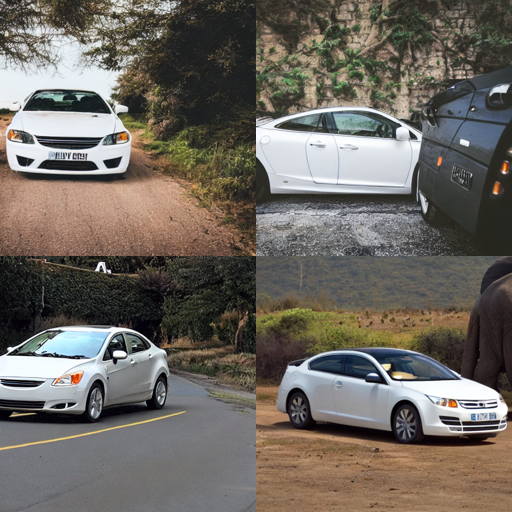

In [6]:
generate_images_for_method(
    prompt="a white car to the left of an elephant",
    indices_to_alter = ([3, 9], [2, None]),
    seeds=[6143, 7792, 8892, 9010],
    is_storm_true=False
)

# STORM

  0%|          | 0/50 [00:00<?, ?it/s]

Iteration 1 | Loss: 0.1513
Iteration 2 | Loss: 0.2672
Iteration 3 | Loss: 0.0332
Iteration 4 | Loss: 0.0315
Iteration 5 | Loss: 0.0295
Iteration 6 | Loss: 0.0268
Iteration 7 | Loss: 0.0265
Iteration 8 | Loss: 0.0275
Iteration 9 | Loss: 0.0243
Iteration 10 | Loss: 0.0253
Iteration 11 | Loss: 0.0213
Iteration 12 | Loss: 0.0229
Iteration 13 | Loss: 0.0252
Iteration 14 | Loss: 0.0265
Iteration 15 | Loss: 0.0285
Iteration 16 | Loss: 0.0295
Iteration 17 | Loss: 0.0338
Iteration 18 | Loss: 0.0363
Iteration 19 | Loss: 0.0369
Iteration 20 | Loss: 0.0418
Iteration 21 | Loss: 0.0412
Iteration 22 | Loss: 0.0435
Iteration 23 | Loss: 0.0432
Iteration 24 | Loss: 0.0440


  0%|          | 0/50 [00:00<?, ?it/s]

Iteration 1 | Loss: 0.1821
Iteration 2 | Loss: 0.2790
Iteration 3 | Loss: 0.0430
Iteration 4 | Loss: 0.0435
Iteration 5 | Loss: 0.0446
Iteration 6 | Loss: 0.0447
Iteration 7 | Loss: 0.0456
Iteration 8 | Loss: 0.0459
Iteration 9 | Loss: 0.0491
Iteration 10 | Loss: 0.0480
Iteration 11 | Loss: 0.0499
Iteration 12 | Loss: 0.0512
Iteration 13 | Loss: 0.0533
Iteration 14 | Loss: 0.0549
Iteration 15 | Loss: 0.0578
Iteration 16 | Loss: 0.0584
Iteration 17 | Loss: 0.0605
Iteration 18 | Loss: 0.0593
Iteration 19 | Loss: 0.0600
Iteration 20 | Loss: 0.0583
Iteration 21 | Loss: 0.0592
Iteration 22 | Loss: 0.0590
Iteration 23 | Loss: 0.0613
Iteration 24 | Loss: 0.0627


  0%|          | 0/50 [00:00<?, ?it/s]

Iteration 1 | Loss: 0.2934
Iteration 2 | Loss: 0.5068
Iteration 3 | Loss: 0.2491
Iteration 4 | Loss: 0.0769
Iteration 5 | Loss: 0.0748
Iteration 6 | Loss: 0.0639
Iteration 7 | Loss: 0.0539
Iteration 8 | Loss: 0.0387
Iteration 9 | Loss: 0.0312
Iteration 10 | Loss: 0.0353
Iteration 11 | Loss: 0.0358
Iteration 12 | Loss: 0.0324
Iteration 13 | Loss: 0.0354
Iteration 14 | Loss: 0.0365
Iteration 15 | Loss: 0.0359
Iteration 16 | Loss: 0.0390
Iteration 17 | Loss: 0.0374
Iteration 18 | Loss: 0.0381
Iteration 19 | Loss: 0.0378
Iteration 20 | Loss: 0.0378
Iteration 21 | Loss: 0.0382
Iteration 22 | Loss: 0.0383
Iteration 23 | Loss: 0.0387
Iteration 24 | Loss: 0.0377


  0%|          | 0/50 [00:00<?, ?it/s]

Iteration 1 | Loss: 0.3208
Iteration 2 | Loss: 0.5558
Iteration 3 | Loss: 0.2916
Iteration 4 | Loss: 0.1594
Iteration 5 | Loss: 0.1457
Iteration 6 | Loss: 0.1295
Iteration 7 | Loss: 0.1264
Iteration 8 | Loss: 0.1255
Iteration 9 | Loss: 0.1255
Iteration 10 | Loss: 0.1261
Iteration 11 | Loss: 0.1236
Iteration 12 | Loss: 0.1239
Iteration 13 | Loss: 0.1235
Iteration 14 | Loss: 0.1235
Iteration 15 | Loss: 0.1227
Iteration 16 | Loss: 0.1252
Iteration 17 | Loss: 0.1245
Iteration 18 | Loss: 0.1289
Iteration 19 | Loss: 0.1314
Iteration 20 | Loss: 0.1337
Iteration 21 | Loss: 0.1389
Iteration 22 | Loss: 0.1392
Iteration 23 | Loss: 0.1422
Iteration 24 | Loss: 0.1428


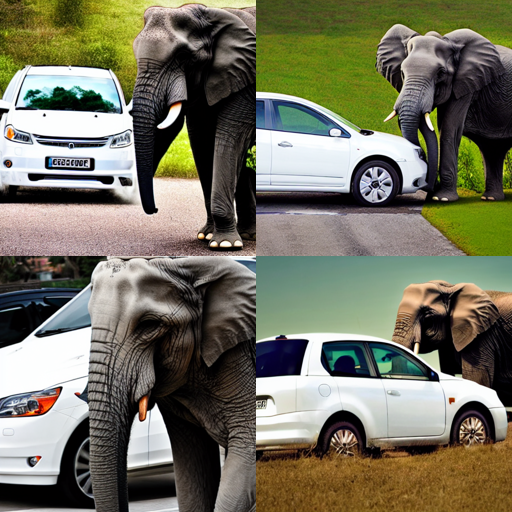

In [7]:
generate_images_for_method(
    prompt="a white car to the left of an elephant",
    indices_to_alter = ([3, 9], [2, None]),
    seeds=[6143, 7792, 8892, 9010],
    is_storm_true=True
)